# 04 – Data Encoding and Visualization

This notebook:
- Verifies that all categorical variables are numerically encoded.
- Visualizes data distributions by key attributes.
- Explores correlation structure among features after imputation.


In [1]:
# --- Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

In [3]:

# --- Mount Google Drive and set paths ---
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/classification_project'
data_path = f'{base_path}/data'
results_path = f'{base_path}/results'
os.makedirs(results_path, exist_ok=True)

Mounted at /content/drive


In [5]:
# --- Load the imputed dataset ---
file_path = f'{data_path}/03_imputed_cirrhosis.csv'
mice_impute_data = pd.read_csv(file_path)
print(f"Dataset loaded successfully from: {file_path}")
print("Shape:", mice_impute_data.shape)
display(mice_impute_data.head())

Dataset loaded successfully from: /content/drive/MyDrive/classification_project/data/03_imputed_cirrhosis.csv
Shape: (418, 19)


,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,1,0.0,21464,1,1.0,1.0,1.0,2,2.740840,5.568345,1.280934,5.056246,7.449498,4.934114,5.153292,5.252273,2.580217,4.0
1,4500,0,0.0,20617,1,0.0,1.0,1.0,0,0.741937,5.713733,1.637053,4.007333,8.908668,4.740749,4.488636,5.402677,2.451005,3.0
2,1012,1,0.0,25594,0,0.0,0.0,0.0,1,0.875469,5.176150,1.499623,5.351858,6.248043,4.575741,4.025352,5.023881,2.564949,4.0
3,1925,1,0.0,19994,1,0.0,1.0,1.0,1,1.029619,5.501258,1.264127,4.174387,8.719775,4.121149,4.532599,5.214936,2.424803,4.0
4,1504,0,1.0,13918,1,0.0,1.0,1.0,0,1.481605,5.634790,1.510722,4.969813,6.510258,4.737513,4.290459,4.919981,2.476538,3.0


### Encoding Verification

All categorical variables should now be numeric.  
Below we double-check the encoding and convert any remaining text columns if necessary.


In [6]:
# --- Confirm datatypes ---
mice_impute_data.info()

# --- Manual re-encoding check (ensures consistency across notebooks) ---
mice_impute_data['Status'].replace({'C': 0, 'D': 1}, inplace=True)
mice_impute_data['Drug'].replace({'D-penicillamine': 0, 'Placebo': 1}, inplace=True)
mice_impute_data['Sex'].replace({'M': 0, 'F': 1}, inplace=True)
mice_impute_data['Ascites'].replace({'N': 0, 'Y': 1}, inplace=True)
mice_impute_data['Hepatomegaly'].replace({'N': 0, 'Y': 1}, inplace=True)
mice_impute_data['Spiders'].replace({'N': 0, 'Y': 1}, inplace=True)
mice_impute_data['Edema'].replace({'N': 0, 'S': 1, 'Y': 2}, inplace=True)

print("Encoding confirmed and standardized across dataset.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         418 non-null    int64  
 1   Status         418 non-null    int64  
 2   Drug           418 non-null    float64
 3   Age            418 non-null    int64  
 4   Sex            418 non-null    int64  
 5   Ascites        418 non-null    float64
 6   Hepatomegaly   418 non-null    float64
 7   Spiders        418 non-null    float64
 8   Edema          418 non-null    int64  
 9   Bilirubin      418 non-null    float64
 10  Cholesterol    418 non-null    float64
 11  Albumin        418 non-null    float64
 12  Copper         418 non-null    float64
 13  Alk_Phos       418 non-null    float64
 14  SGOT           418 non-null    float64
 15  Tryglicerides  418 non-null    float64
 16  Platelets      418 non-null    float64
 17  Prothrombin    418 non-null    float64
 18  Stage     

/tmp/ipython-input-2147353729.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mice_impute_data['Status'].replace({'C': 0, 'D': 1}, inplace=True)
/tmp/ipython-input-2147353729.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

### Feature Distributions

We visualize key features to understand the balance of categorical variables and the shape of numerical ones.


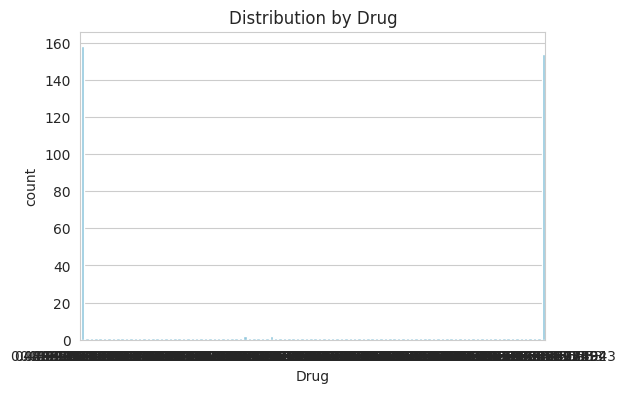

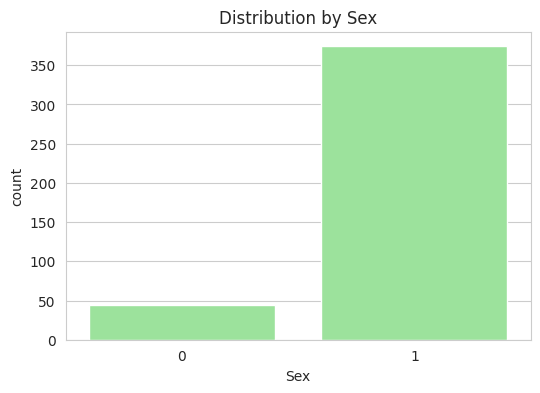

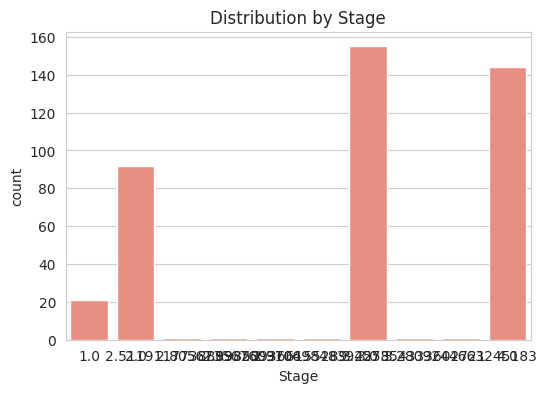

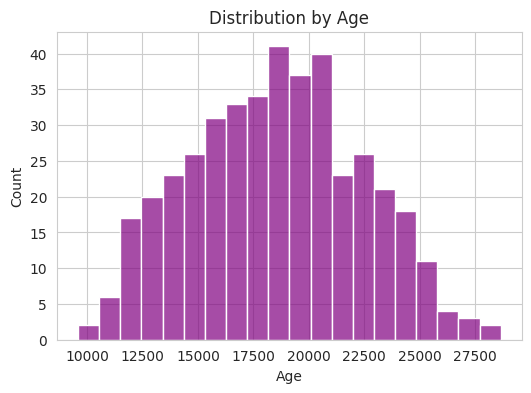

In [7]:
# --- Visualizations ---
sns.set_style('whitegrid')

# Distribution by Drug
plt.figure(figsize=(6, 4))
sns.countplot(x='Drug', data=mice_impute_data, color='skyblue')
plt.title('Distribution by Drug')
plt.savefig(f'{results_path}/04_distribution_drug.png', bbox_inches='tight')
plt.show()

# Distribution by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', data=mice_impute_data, color='lightgreen')
plt.title('Distribution by Sex')
plt.savefig(f'{results_path}/04_distribution_sex.png', bbox_inches='tight')
plt.show()

# Distribution by Stage
plt.figure(figsize=(6, 4))
sns.countplot(x='Stage', data=mice_impute_data, color='salmon')
plt.title('Distribution by Stage')
plt.savefig(f'{results_path}/04_distribution_stage.png', bbox_inches='tight')
plt.show()

# Distribution by Age
plt.figure(figsize=(6, 4))
sns.histplot(mice_impute_data['Age'], bins=20, color='purple', alpha=0.7)
plt.title('Distribution by Age')
plt.savefig(f'{results_path}/04_distribution_age.png', bbox_inches='tight')
plt.show()

### Correlation Matrix

Inspect correlations between numeric features to identify redundancies and potentially predictive variables.


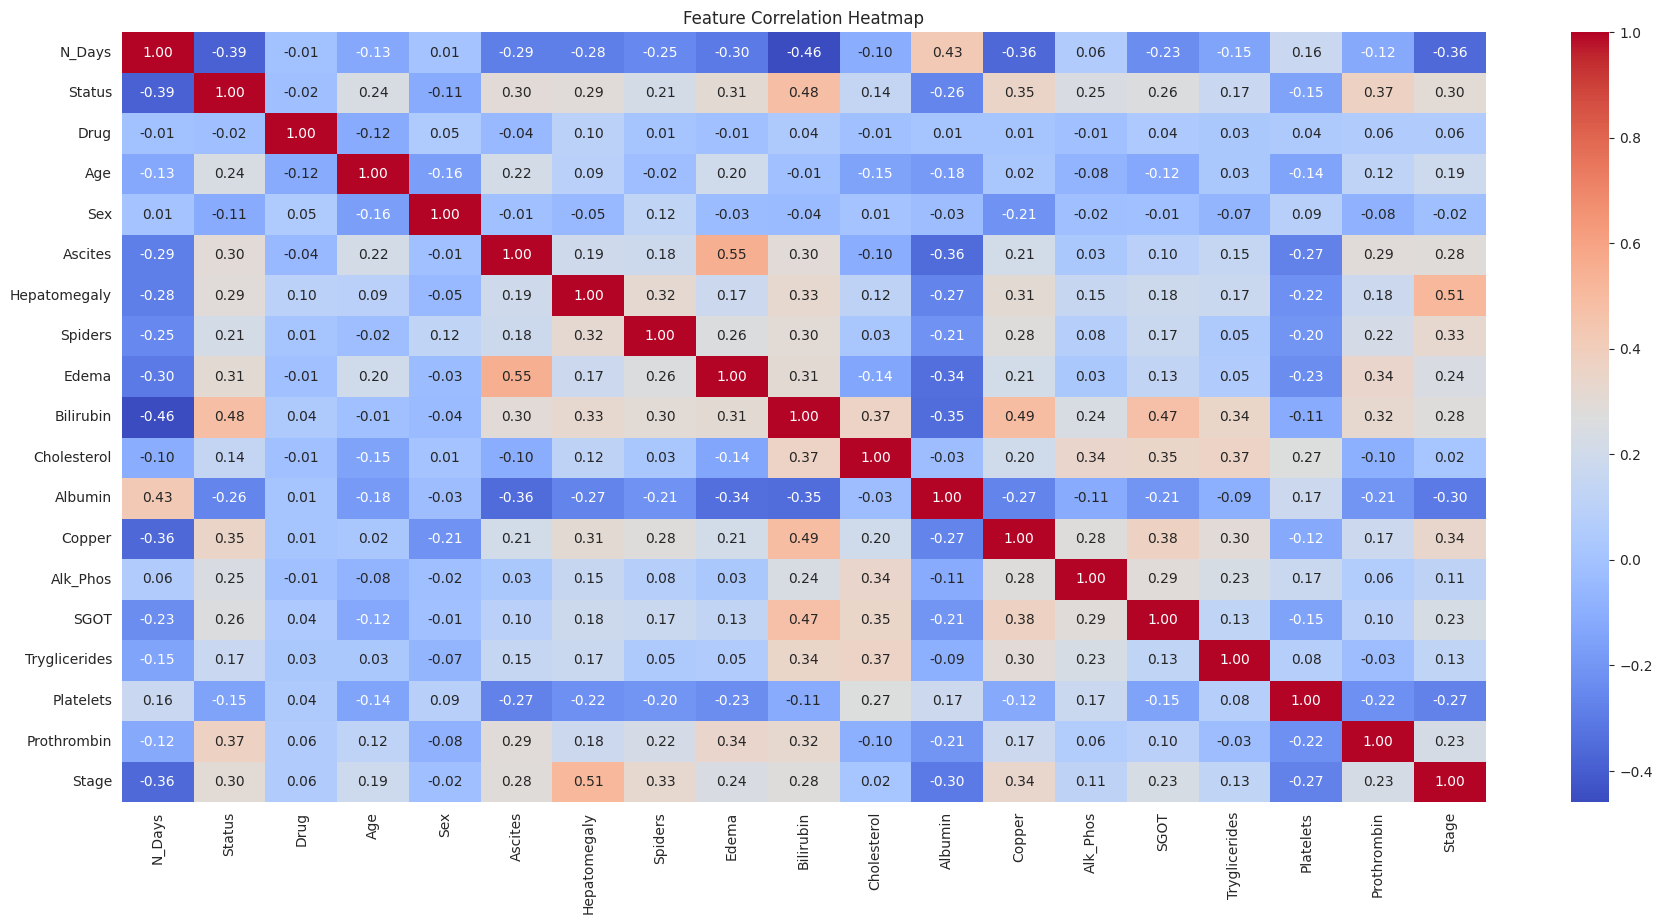

In [8]:
# --- Correlation Heatmap ---
plt.figure(figsize=(22, 10))
sns.heatmap(mice_impute_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig(f'{results_path}/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Class Balance

We now examine the imbalance in our target variable (`Status`) to decide on balancing strategies.


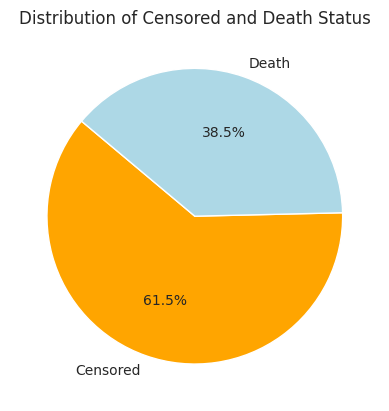

In [9]:
# --- Status distribution pie chart ---
status_counts = mice_impute_data['Status'].value_counts()
status_counts.plot(
    kind='pie',
    labels=["Censored", "Death"],
    colors=['orange', 'lightblue'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Distribution of Censored and Death Status')
plt.ylabel('')
plt.savefig(f'{results_path}/04_status_pie_chart.png', bbox_inches='tight')
plt.show()

In [10]:

# --- Save encoded dataset for next stage ---
save_path = f'{data_path}/04_encoded_cirrhosis.csv'
mice_impute_data.to_csv(save_path, index=False)
print(f"Encoded dataset saved to: {save_path}")

Encoded dataset saved to: /content/drive/MyDrive/classification_project/data/04_encoded_cirrhosis.csv


**Next Notebook:** [05_Handling_Imbalance_SMOTE.ipynb](05_Handling_Imbalance_SMOTE.ipynb)

We will apply the SMOTE technique to balance the dataset and prepare it for model development.
